In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("youtube_videos.csv")

In [3]:
df.head(10)

,video_id,title,description,published_at,viewCount,likeCount,commentCount,duration
0,UigGPZYdyoo,Just LEARN THESE 6 courses to Make Money Onlin...,"In this video, I break down how you can shift ...",2025-12-04 10:30:31+00:00,1831,120,15,603
1,n5Ev-klyqXc,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,"Don't forget to like, comment, and subscribe f...",2025-12-02 10:30:40+00:00,6310,588,20,78
2,fR-2AiAxDhk,"POV: I Made ₹2,687 in 60- Minutes from the Eas...","POV: I Made ₹2,687 in 1 hour from the Easiest ...",2025-11-27 10:30:27+00:00,5897,265,47,481
3,Ze1t4p0QCT0,"You know that phase when life says 'Bas, ho gy...","Don't forget to like, comment, and subscribe f...",2025-11-25 10:30:32+00:00,8944,666,4,61
4,Tr6Z8guOdM4,Complete Beginners Guide To Affinity Pixel Stu...,Complete Beginners Guide To Affinity Pixel Stu...,2025-11-20 10:30:31+00:00,2257,94,30,2140
5,0eIDN3uZiCg,I’m super excited for this new journey. I hope...,"Time for a cool introduction, right?\nWill the...",2025-11-18 10:30:01+00:00,15161,812,11,43
6,fbd903qIEns,7 Lessons for my Younger Self! (Watch this if ...,7 Things I wish I knew BEFORE 2025 started (My...,2025-11-13 10:30:25+00:00,3682,250,61,1152
7,fPpBv7UGHT4,"My story of comeback 💖 Reset, recharge but don...","Don't forget to like, comment, and subscribe f...",2025-11-11 10:30:24+00:00,10638,560,10,55
8,stegnhfnk6s,Complete Beginners Guide To 2025 🔥 Full Affin...,Complete Beginners Guide To 2025 🔥 Full Canva...,2025-11-06 10:30:43+00:00,31472,1155,123,1755
9,mcbAB1mNU7c,Design Your Portfolio on Behance in 30 Minutes...,Want to build a professional Behance portfolio...,2025-10-30 10:30:38+00:00,7322,306,42,1795


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_id      491 non-null    object
 1   title         491 non-null    object
 2   description   405 non-null    object
 3   published_at  491 non-null    object
 4   viewCount     491 non-null    int64 
 5   likeCount     491 non-null    int64 
 6   commentCount  491 non-null    int64 
 7   duration      491 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 30.8+ KB


In [5]:
df.describe()

,viewCount,likeCount,commentCount,duration
count,4.910000e+02,491.000000,491.000000,491.000000
mean,4.669661e+04,1785.690428,116.437882,819.087576
std,1.308113e+05,4487.456712,171.425326,1387.158621
min,8.930000e+02,40.000000,1.000000,11.000000
25%,6.108000e+03,362.500000,19.000000,59.000000
50%,1.214900e+04,682.000000,67.000000,552.000000
75%,3.163700e+04,1380.000000,146.000000,922.000000
max,1.785057e+06,72330.000000,2035.000000,19241.000000


In [6]:
df['published_at'] = pd.to_datetime(df['published_at'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   video_id      491 non-null    object             
 1   title         491 non-null    object             
 2   description   405 non-null    object             
 3   published_at  491 non-null    datetime64[ns, UTC]
 4   viewCount     491 non-null    int64              
 5   likeCount     491 non-null    int64              
 6   commentCount  491 non-null    int64              
 7   duration      491 non-null    int64              
dtypes: datetime64[ns, UTC](1), int64(4), object(3)
memory usage: 30.8+ KB


In [8]:
df.isnull().sum()

video_id         0
title            0
description     86
published_at     0
viewCount        0
likeCount        0
commentCount     0
duration         0
dtype: int64

In [9]:
df = df.drop(['video_id', 'description'], axis = 1)

In [10]:
df['title_length'] = df['title'].str.len()

In [11]:
df.head()

,title,published_at,viewCount,likeCount,commentCount,duration,title_length
0,Just LEARN THESE 6 courses to Make Money Onlin...,2025-12-04 10:30:31+00:00,1831,120,15,603,55
1,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,2025-12-02 10:30:40+00:00,6310,588,20,78,50
2,"POV: I Made ₹2,687 in 60- Minutes from the Eas...",2025-11-27 10:30:27+00:00,5897,265,47,481,72
3,"You know that phase when life says 'Bas, ho gy...",2025-11-25 10:30:32+00:00,8944,666,4,61,73
4,Complete Beginners Guide To Affinity Pixel Stu...,2025-11-20 10:30:31+00:00,2257,94,30,2140,95


In [12]:
df.dtypes

title                        object
published_at    datetime64[ns, UTC]
viewCount                     int64
likeCount                     int64
commentCount                  int64
duration                      int64
title_length                  int64
dtype: object

In [13]:
df['engagement_rate'] = (df['likeCount'] + df['commentCount']) / df['viewCount']

In [14]:
df['day_of_week'] = df['published_at'].dt.day_name()

In [15]:
df.head(2)

,title,published_at,viewCount,likeCount,commentCount,duration,title_length,engagement_rate,day_of_week
0,Just LEARN THESE 6 courses to Make Money Onlin...,2025-12-04 10:30:31+00:00,1831,120,15,603,55,0.073730,Thursday
1,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,2025-12-02 10:30:40+00:00,6310,588,20,78,50,0.096355,Tuesday


In [16]:
df['hour'] = df['published_at'].dt.hour

### Views vs Posting hour


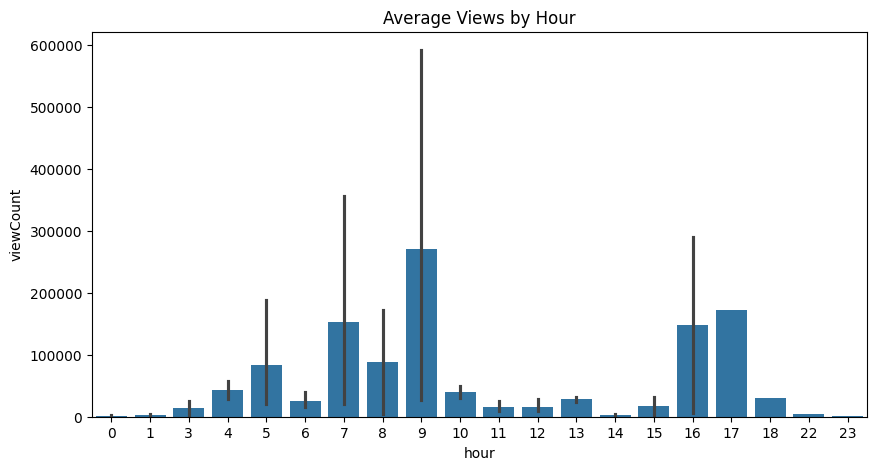

In [17]:
plt.figure(figsize = (10,5))
sns.barplot(x = 'hour', y = 'viewCount', data = df)
plt.title("Average Views by Hour")
plt.show()

### Views vs Posting day

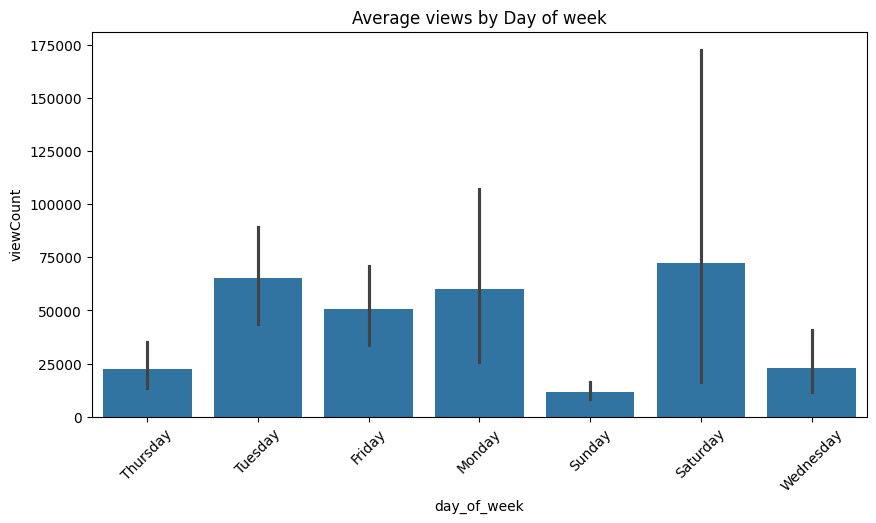

In [18]:
plt.figure(figsize = (10,5))
sns.barplot(x = 'day_of_week', y = 'viewCount', data = df)
plt.title("Average views by Day of week")
plt.xticks(rotation = 45)
plt.show()

### Engagement Rate distribution

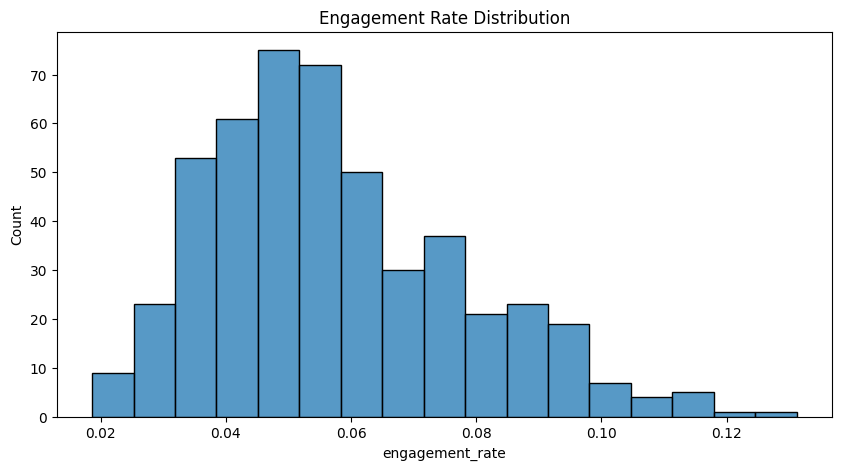

In [19]:
plt.figure(figsize = (10,5))
sns.histplot(df['engagement_rate'])
plt.title("Engagement Rate Distribution")
plt.show()

## ML modeling

### Outlier detection

In [20]:
def outlier_detect(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df[(df[column] < lower) | (df[column] > upper)]

outliers = outlier_detect(df, 'engagement_rate')
outliers.head()

,title,published_at,viewCount,likeCount,commentCount,duration,title_length,engagement_rate,day_of_week,hour
82,10 FREE Graphic Design Tools!,2025-01-24 11:54:58+00:00,14094,1816,33,44,29,0.131191,Friday,11
135,5 Podcasts that every designer must listen 🎧,2024-10-12 04:30:10+00:00,2797,324,6,61,45,0.117984,Saturday,4
140,Freelancing Strategy for Beginners 🚀 #shorts #...,2024-10-04 10:30:32+00:00,3434,377,14,58,57,0.113861,Friday,10
147,This happened 🫠 #shorts,2024-09-07 04:35:00+00:00,8964,954,36,40,23,0.110442,Saturday,4
170,New Freelancers assemble here 🔥 #shorts,2024-07-18 06:23:40+00:00,14084,1563,27,39,39,0.112894,Thursday,6


In [21]:
outlierz = outlier_detect(df , 'viewCount')
outlierz[['title', 'viewCount']]

,title,viewCount
37,How to make money using Mobile Phone in 2025: ...,71141
45,Learn Photoshop in 60 Minutes | Photoshop Tuto...,149407
47,How to ACTUALLY Make Money with Copywriting in...,125873
70,Full Graphic Design Premium Crash Course for B...,513118
80,17 ways to make money using Canva + Roadmap (J...,90877
...,...,...
484,How To Rank Gig on Fiverr 2021| How to get 1st...,93286
485,HOW TO EARN MONEY WITH CANVA ON FIVERR | Freel...,171846
487,Fiverr tutorial for beginners | Part -2 | how ...,432315
488,How To Create Seller Account on Fiverr | Fiver...,548553


#### Visualizing outliers

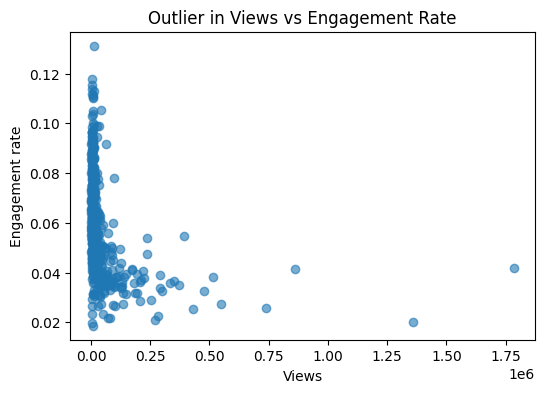

In [22]:
plt.figure(figsize = (6,4))
plt.scatter(df['viewCount'], df['engagement_rate'], alpha = 0.6)
plt.xlabel("Views")
plt.ylabel("Engagement rate")
plt.title("Outlier in Views vs Engagement Rate")
plt.show()

##### Shruti's videos show a clear negative trend between views and engagement.
##### Most videos with 0–200k views achieve stable engagement (3–6%), while viral videos (500k+ views) have lower engagement.


In [23]:
df.info

<bound method DataFrame.info of                                                  title  \
0    Just LEARN THESE 6 courses to Make Money Onlin...   
1    My journey ❤️🤍 I just felt like sharing 🫠❤️  #...   
2    POV: I Made ₹2,687 in 60- Minutes from the Eas...   
3    You know that phase when life says 'Bas, ho gy...   
4    Complete Beginners Guide To Affinity Pixel Stu...   
..                                                 ...   
486  How to Become A Content Writer? | Now get paid...   
487  Fiverr tutorial for beginners | Part -2 | how ...   
488  How To Create Seller Account on Fiverr | Fiver...   
489  Freelancing | freelancing skills | Best websit...   
490  I Earned $10 in just 30 minutes using Canva: L...   

                 published_at  viewCount  likeCount  commentCount  duration  \
0   2025-12-04 10:30:31+00:00       1831        120            15       603   
1   2025-12-02 10:30:40+00:00       6310        588            20        78   
2   2025-11-27 10:30:27+00:00     

In [24]:
df.head(2)

,title,published_at,viewCount,likeCount,commentCount,duration,title_length,engagement_rate,day_of_week,hour
0,Just LEARN THESE 6 courses to Make Money Onlin...,2025-12-04 10:30:31+00:00,1831,120,15,603,55,0.073730,Thursday,10
1,My journey ❤️🤍 I just felt like sharing 🫠❤️ #...,2025-12-02 10:30:40+00:00,6310,588,20,78,50,0.096355,Tuesday,10


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   title            491 non-null    object             
 1   published_at     491 non-null    datetime64[ns, UTC]
 2   viewCount        491 non-null    int64              
 3   likeCount        491 non-null    int64              
 4   commentCount     491 non-null    int64              
 5   duration         491 non-null    int64              
 6   title_length     491 non-null    int64              
 7   engagement_rate  491 non-null    float64            
 8   day_of_week      491 non-null    object             
 9   hour             491 non-null    int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(5), object(2)
memory usage: 36.6+ KB


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


In [30]:
tfidf = TfidfVectorizer(stop_words='english', max_features = 500)
title_matrix = tfidf.fit_transform(df['title'])
print(title_matrix)
print(tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2719 stored elements and shape (491, 500)>
  Coords	Values
  (0, 241)	0.3974088054129165
  (0, 265)	0.4223546723148762
  (0, 79)	0.5623491378891894
  (0, 285)	0.3239627308147725
  (0, 311)	0.301961969327348
  (0, 333)	0.38899015076521226
  (1, 241)	0.31013269124122944
  (1, 239)	0.36966530171493445
  (1, 141)	0.49118619192298074
  (1, 274)	0.4082352795075171
  (1, 422)	0.4388499931941647
  (1, 477)	0.4082352795075171
  (2, 378)	0.487896880065296
  (2, 35)	0.4691653609261518
  (2, 303)	0.3133406412347139
  (2, 106)	0.4691653609261518
  (2, 63)	0.245268071912836
  (2, 335)	0.3307706799361539
  (2, 148)	0.23232807704186387
  (3, 477)	0.3197660272448977
  (3, 253)	0.28955460459534943
  (3, 360)	0.38474052859478375
  (3, 273)	0.3027518363445599
  (3, 199)	0.38474052859478375
  (3, 185)	0.38474052859478375
  :	:
  (488, 148)	0.5004951704161134
  (488, 52)	0.1902058182011348
  (488, 466)	0.22315089285231707
  (488, 81)	0.2231508928

In [ ]:
kmeans = KMeans(n_clusters = 5, random_state = 42)
df['topic_cluster'] = kmeans.fit_predict(title_matrix)
# videos are now grouped into 5 topic categories.

In [33]:
topic_analysis = df.groupby('topic_cluster')[['viewCount','engagement_rate']].mean()
topic_analysis['video_count'] = df['topic_cluster'].value_counts()

In [34]:
best_topic = topic_analysis.sort_values(by = 'viewCount', ascending=False)
print("Topic performance summary:")
print(best_topic)

Topic performance summary:
                   viewCount  engagement_rate  video_count
topic_cluster                                             
4              106848.186667         0.045504           75
2               81828.382353         0.059916           34
3               38268.850000         0.055437          220
0               36335.600000         0.053982           65
1               13930.896907         0.073414           97


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [36]:
print(df['day_of_week'])

0       Thursday
1        Tuesday
2       Thursday
3        Tuesday
4       Thursday
         ...    
486    Wednesday
487     Saturday
488       Friday
489       Monday
490     Saturday
Name: day_of_week, Length: 491, dtype: object


In [37]:
X = df[['title','title_length','day_of_week','hour']]
y = df['viewCount']

In [38]:
prepro = ColumnTransformer(
    transformers= [
        ('text', TfidfVectorizer(stop_words = 'english'), 'title'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['day_of_week'])
        ], remainder = 'passthrough'
)

In [39]:
model = Pipeline([
    ('prep' , prepro),
    ('regressor', RandomForestRegressor(n_estimators= 100, random_state= 42))
])

In [40]:
model.fit(X,y)
#model trained

,steps,"[('prep', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
